# Indic Embedding Language Alignment Benchmark — Colab Version

This notebook benchmarks Indic/multilingual embedding models for **cross-lingual semantic alignment**.

Main question:

> If two sentences mean the same thing in English and an Indic language, do their embeddings become close?

We test this using FLORES translation pairs and compute:

- **Positive cosine mean**: similarity of true translation pairs
- **Random cosine mean**: similarity of mismatched pairs
- **Cosine gap**: positive mean − random mean
- **Accuracy@1**: whether the correct translation is the nearest neighbor
- **Recall@5 / Recall@10 / MRR**

Start small with `QUICK_N = 100`, then increase to 250 or full devtest.


## 0. Colab GPU setup

In Colab, go to:

**Runtime → Change runtime type → Hardware accelerator → GPU → Save**

Then run the next cell.

In [ ]:
from pathlib import Path
import sys

for _candidate in (Path.cwd(), *Path.cwd().parents):
    _guard_dir = _candidate / "scripts"
    if (_guard_dir / "import_guard.py").exists():
        if str(_guard_dir) not in sys.path:
            sys.path.insert(0, str(_guard_dir))
        break
else:
    raise RuntimeError("Could not locate scripts/import_guard.py. Run this notebook from the WSAI workspace or copy the guard module alongside it.")

from import_guard import install_pandas_guards
install_pandas_guards()


In [1]:
# Clean broken vision packages. We do not need these for text embeddings.
!pip -q uninstall -y torchvision torchaudio torchtext fastai timm -q

# Install only text/NLP packages.
# Do NOT install torch manually. Let Colab keep its own working GPU torch.
!pip -q install \
  "numpy==2.0.2" \
  "scipy==1.15.3" \
  "scikit-learn==1.6.1" \
  "transformers==4.48.3" \
  "sentence-transformers==3.4.1" \
  "accelerate==1.3.0" \
  "pandas==2.2.2" \
  "tqdm==4.67.1" \
  "matplotlib==3.10.0" \
  "pyyaml==6.0.2" \
  "sentencepiece==0.2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.0 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import scipy
import sklearn
import transformers
import sentence_transformers
import pandas as pd

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("pandas:", pd.__version__)

torch: 2.10.0+cu128
cuda available: True
numpy: 2.0.2
scipy: 1.15.3
sklearn: 1.6.1
transformers: 4.48.3
sentence-transformers: 3.4.1
pandas: 2.2.2


## 1. Install dependencies

Run this once per fresh Colab session. After installing, Colab may ask you to restart the runtime. If it does, restart and continue from the next cells.

## 2. Optional: mount Google Drive

This saves embeddings and CSV results permanently. If you do not mount Drive, results will stay only in the Colab runtime.

In [3]:
from google.colab import drive
USE_DRIVE = True

if USE_DRIVE:
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/indic_embedding_benchmark'
else:
    BASE_DIR = '/content/indic_embedding_benchmark'

print('Saving outputs to:', BASE_DIR)

Mounted at /content/drive
Saving outputs to: /content/drive/MyDrive/indic_embedding_benchmark


## 3. Imports and configuration

First run only 100 examples. Once the notebook works, change:

```python
QUICK_N = 250
```

Later, for full devtest:

```python
QUICK_N = 0
```


In [4]:
import gc
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from datasets import load_dataset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

SEED = 42
SPLITS = ["dev", "devtest"]
QUICK_N = 0      # start with 100; later use 250; use 0 for full split
BATCH_SIZE = 32    # safe for Colab T4; increase to 32 if memory is fine
MAX_LENGTH = 128

OUTPUT_DIR = Path(BASE_DIR) / 'outputs' / 'flores_alignment_colab'
(OUTPUT_DIR / 'embeddings').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'errors').mkdir(parents=True, exist_ok=True)

LANGS = {
    "eng": "eng_Latn",   # English reference

    "asm": "asm_Beng",   # Assamese
    "ben": "ben_Beng",   # Bengali
    "guj": "guj_Gujr",   # Gujarati
    "hin": "hin_Deva",   # Hindi
    "kan": "kan_Knda",   # Kannada
    "mal": "mal_Mlym",   # Malayalam
    "mar": "mar_Deva",   # Marathi
    "npi": "npi_Deva",   # Nepali
    "ory": "ory_Orya",   # Odia
    "pan": "pan_Guru",   # Punjabi
    "snd": "snd_Arab",   # Sindhi
    "tam": "tam_Taml",   # Tamil
    "tel": "tel_Telu",   # Telugu
    "urd": "urd_Arab",   # Urdu
}
# Start with 3 models if you want a fast first run.
# Then add the remaining models.
MODELS = [
    # Existing models
    {
        'name': 'labse',
        'hf_id': 'sentence-transformers/LaBSE',
        'kind': 'sentence_transformer'
    },
    {
        'name': 'mpnet_multilingual',
        'hf_id': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
        'kind': 'sentence_transformer'
    },
    {
        'name': 'muril',
        'hf_id': 'google/muril-base-cased',
        'kind': 'hf_mean_pool'
    },
    {
        'name': 'indicbertv2_ss',
        'hf_id': 'ai4bharat/IndicBERTv2-SS',
        'kind': 'hf_mean_pool',
        'trust_remote_code': True
    },
    {
        'name': 'xlm_roberta_base',
        'hf_id': 'FacebookAI/xlm-roberta-base',
        'kind': 'hf_mean_pool'
    },

    # Added from papers we read

    # SBERT-style multilingual sentence-transformer baseline
    {
        'name': 'sbert_multilingual_minilm',
        'hf_id': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
        'kind': 'sentence_transformer'
    },

    # SimCSE original-style model
    # Mostly English, so use it as a paper baseline, not the strongest Indic model
    {
        'name': 'simcse_roberta_supervised',
        'hf_id': 'princeton-nlp/sup-simcse-roberta-base',
        'kind': 'hf_mean_pool'
    },

    # Multilingual SimCSE-style model, better choice for cross-lingual benchmark
    {
        'name': 'simcse_xlmr_multilingual',
        'hf_id': 'ZurichNLP/unsup-simcse-xlm-roberta-base',
        'kind': 'hf_mean_pool'
    },

    # Contriever: dense retrieval model
    # Mostly useful as retrieval baseline
    {
        'name': 'contriever',
        'hf_id': 'facebook/contriever',
        'kind': 'hf_mean_pool'
    },

    # mContriever: multilingual Contriever
    # More important for your Indic alignment benchmark
    {
        'name': 'mcontriever',
        'hf_id': 'facebook/mcontriever',
        'kind': 'hf_mean_pool'
    },
]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Output dir:', OUTPUT_DIR)

Device: cuda
Output dir: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab


## 4. Load FLORES parallel sentences

FLORES rows align by index across languages. So row `i` in English is the translation pair for row `i` in Hindi/Tamil/etc.

In [5]:
from typing import Dict, List
from pathlib import Path
import urllib.request
import tarfile
import shutil
import os
FLORES_URL = "https://dl.fbaipublicfiles.com/nllb/flores200_dataset.tar.gz"
FLORES_CACHE_DIR = Path("/content/flores200_cache")

def download_file(url: str, output_path: Path):
    req = urllib.request.Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(req) as response, open(output_path, "wb") as out_file:
        shutil.copyfileobj(response, out_file)


def ensure_flores200_downloaded(cache_dir: Path = FLORES_CACHE_DIR) -> Path:
    cache_dir.mkdir(parents=True, exist_ok=True)

    dataset_dir = cache_dir / "flores200_dataset"
    tar_path = cache_dir / "flores200_dataset.tar.gz"

    # If already extracted, use it directly
    if dataset_dir.exists():
        print("FLORES-200 already extracted.")
        return dataset_dir

    # Remove old broken zip/html file from previous attempt if present
    old_bad_zip = cache_dir / "flores200_dataset.zip"
    if old_bad_zip.exists():
        old_bad_zip.unlink()

    # Download tar.gz
    if not tar_path.exists():
        print("Downloading FLORES-200 tar.gz...")
        download_file(FLORES_URL, tar_path)

    # Safety check: if downloaded file is bad HTML, delete and stop clearly
    if not tarfile.is_tarfile(tar_path):
        with open(tar_path, "rb") as f:
            preview = f.read(300)
        tar_path.unlink()
        raise RuntimeError(
            "Downloaded file is not a tar.gz file. "
            "Maybe the redirect was blocked. Preview:\n"
            f"{preview[:300]}"
        )

    print("Extracting FLORES-200...")
    with tarfile.open(tar_path, "r:*") as tar:
        tar.extractall(cache_dir)

    if not dataset_dir.exists():
        candidates = list(cache_dir.rglob("flores200_dataset"))
        if not candidates:
            raise FileNotFoundError("Could not find extracted flores200_dataset folder.")
        dataset_dir = candidates[0]

    return dataset_dir


def load_flores_sentences(
    langs: Dict[str, str],
    split: str,
    quick_n: int
) -> Dict[str, List[str]]:

    flores_dir = ensure_flores200_downloaded()
    all_texts = {}

    for short, flores_code in langs.items():
        print(f"Loading {short} / {flores_code}")

        file_path = flores_dir / split / f"{flores_code}.{split}"

        if not file_path.exists():
            raise FileNotFoundError(f"Missing FLORES file: {file_path}")

        with open(file_path, "r", encoding="utf-8") as f:
            texts = [line.strip() for line in f if line.strip()]

        if quick_n and quick_n > 0:
            texts = texts[:quick_n]
        print(f"Loaded {short , len(texts)} sentences.")

        all_texts[short] = texts

    lengths = {lang: len(texts) for lang, texts in all_texts.items()}
    print("Loaded lengths:", lengths)

    if len(set(lengths.values())) != 1:
        raise ValueError(f"Language lengths are not equal: {lengths}")

    return all_texts


def load_flores_sentences_multi_split(
    langs: Dict[str, str],
    splits: List[str],
    quick_n: int
) -> Dict[str, List[str]]:

    flores_dir = ensure_flores200_downloaded()
    all_texts = {short: [] for short in langs}

    for split in splits:
        print(f"\nLoading split: {split}")

        for short, flores_code in langs.items():
            print(f"Loading {short} / {flores_code}")

            file_path = flores_dir / split / f"{flores_code}.{split}"

            if not file_path.exists():
                raise FileNotFoundError(f"Missing FLORES file: {file_path}")

            with open(file_path, "r", encoding="utf-8") as f:
                texts = [line.strip() for line in f if line.strip()]

            all_texts[short].extend(texts)
            print(f"Loaded {short}: {len(texts)} sentences from {split}")

    if quick_n and quick_n > 0:
        for short in all_texts:
            all_texts[short] = all_texts[short][:quick_n]

    lengths = {lang: len(texts) for lang, texts in all_texts.items()}
    print("\nTotal loaded lengths:", lengths)

    if len(set(lengths.values())) != 1:
        raise ValueError(f"Language lengths are not equal: {lengths}")

    return all_texts

texts_by_lang = load_flores_sentences_multi_split(LANGS, SPLITS, QUICK_N)

print("Example:")
print("EN:", texts_by_lang["eng"][10])
print("HI:", texts_by_lang["hin"][10])

Extracting FLORES-200...


/tmp/ipykernel_424/545197014.py:54: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(cache_dir)



Loading split: dev
Loading eng / eng_Latn
Loaded eng: 997 sentences from dev
Loading asm / asm_Beng
Loaded asm: 997 sentences from dev
Loading ben / ben_Beng
Loaded ben: 997 sentences from dev
Loading guj / guj_Gujr
Loaded guj: 997 sentences from dev
Loading hin / hin_Deva
Loaded hin: 997 sentences from dev
Loading kan / kan_Knda
Loaded kan: 997 sentences from dev
Loading mal / mal_Mlym
Loaded mal: 997 sentences from dev
Loading mar / mar_Deva
Loaded mar: 997 sentences from dev
Loading npi / npi_Deva
Loaded npi: 997 sentences from dev
Loading ory / ory_Orya
Loaded ory: 997 sentences from dev
Loading pan / pan_Guru
Loaded pan: 997 sentences from dev
Loading snd / snd_Arab
Loaded snd: 997 sentences from dev
Loading tam / tam_Taml
Loaded tam: 997 sentences from dev
Loading tel / tel_Telu
Loaded tel: 997 sentences from dev
Loading urd / urd_Arab
Loaded urd: 997 sentences from dev

Loading split: devtest
Loading eng / eng_Latn
Loaded eng: 1012 sentences from devtest
Loading asm / asm_Beng


## 5. Embedding helpers

Sentence-transformer models use their built-in pooling. Raw backbone models use attention-mask-aware mean pooling.

In [19]:

@dataclass
class ModelSpec:
    name: str
    hf_id: str
    kind: str
    trust_remote_code: bool = False


def mean_pool(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Mean pooling:
    Takes token embeddings and averages only the real tokens,
    ignoring padding tokens.
    """
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

class Embedder:
    def __init__(self, spec: ModelSpec, device: str, max_length: int):
        self.spec = spec
        self.device = device
        self.max_length = max_length

        if spec.kind == "sentence_transformer":
            from sentence_transformers import SentenceTransformer

            print("Loading as SentenceTransformer:", spec.hf_id)

            self.model = SentenceTransformer(
                spec.hf_id,
                device=device,
                trust_remote_code=spec.trust_remote_code,
            )

            # Save GPU memory on Colab
            if device == "cuda":
                self.model = self.model.half()

            self.tokenizer = None

        elif spec.kind == "hf_mean_pool":
            from transformers import AutoModel, AutoTokenizer

            print("Loading as HF mean-pool model:", spec.hf_id)

            self.tokenizer = AutoTokenizer.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
            )

            dtype = torch.float16 if device == "cuda" else torch.float32

            self.model = AutoModel.from_pretrained(
                spec.hf_id,
                trust_remote_code=spec.trust_remote_code,
                torch_dtype=dtype,
            )

            self.model.to(device)
            self.model.eval()

        else:
            raise ValueError(f"Unknown model kind: {spec.kind}")

    @torch.no_grad()
    def encode(self, texts: List[str], batch_size: int) -> np.ndarray:

        if self.spec.kind == "sentence_transformer":
            emb = self.model.encode(
                texts,
                batch_size=batch_size,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=True,
            )
            return emb.astype("float32")

        all_embeddings = []

        for start in tqdm(
            range(0, len(texts), batch_size),
            desc=f"Encoding {self.spec.name}"
        ):
            batch = texts[start:start + batch_size]

            # IMPORTANT:
            # Do not add any extra argument like f=True here.
            # This is the correct tokenizer call.
            encoded = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt",
            )

            encoded = {k: v.to(self.device) for k, v in encoded.items()}

            outputs = self.model(**encoded)

            pooled = mean_pool(
                outputs.last_hidden_state,
                encoded["attention_mask"]
            )

            pooled = F.normalize(pooled, p=2, dim=1)

            all_embeddings.append(
                pooled.detach().cpu().float().numpy()
            )

        return np.vstack(all_embeddings).astype("float32")


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 6. Metric functions

In [20]:
def compute_retrieval_metrics(src_emb: np.ndarray, tgt_emb: np.ndarray, top_ks: Tuple[int, ...] = (1, 5, 10)) -> Dict[str, float]:
    sim = np.matmul(src_emb, tgt_emb.T)
    n = sim.shape[0]
    sorted_idx = np.argsort(-sim, axis=1)
    ranks = np.empty(n, dtype=np.int64)

# For each source sentence i, the correct target translation is also at index i
# because FLORES is index-aligned: English row i ↔ Hindi/Tamil/etc. row i.
# sorted_idx[i] contains target sentence indexes sorted from most similar to least similar.
# This loop finds where the correct target index i appears in that sorted list.
# That position + 1 is the rank:
# rank 1 = correct translation is the nearest neighbour
# rank 2 = correct translation is the second nearest neighbour
# rank 10 = correct translation is the tenth nearest neighbour

    for i in range(n):
        ranks[i] = int(np.where(sorted_idx[i] == i)[0][0]) + 1

    out = {
        'mrr': float(np.mean(1.0 / ranks)),
        'mean_rank': float(np.mean(ranks)),
        'median_rank': float(np.median(ranks)),
    }
    for k in top_ks:
        out[f'recall_at_{k}'] = float(np.mean(ranks <= k))
    out['accuracy_at_1'] = out['recall_at_1']
    return out


def compute_cosine_gap(src_emb: np.ndarray, tgt_emb: np.ndarray, seed: int = 42) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    n = src_emb.shape[0]
    pos = np.sum(src_emb * tgt_emb, axis=1)

    neg_idx = rng.permutation(n)
    for i in range(n):
        if neg_idx[i] == i:
            neg_idx[i] = (neg_idx[i] + 1) % n
    neg = np.sum(src_emb * tgt_emb[neg_idx], axis=1)

    return {
        'positive_cosine_mean': float(np.mean(pos)),
        'positive_cosine_std': float(np.std(pos)),
        'random_cosine_mean': float(np.mean(neg)),
        'random_cosine_std': float(np.std(neg)),
        'cosine_gap': float(np.mean(pos) - np.mean(neg)),
    }


def collect_errors(src_texts, tgt_texts, src_emb, tgt_emb, n_examples=25):
    sim = np.matmul(src_emb, tgt_emb.T)
    pred_idx = np.argmax(sim, axis=1)
    rows = []
    for i, p in enumerate(pred_idx):
        if p != i:
            rows.append({
                'row_id': i,
                'source_text': src_texts[i],
                'gold_translation': tgt_texts[i],
                'predicted_neighbor': tgt_texts[p],
                'gold_cosine': float(sim[i, i]),
                'predicted_cosine': float(sim[i, p]),
                'margin_pred_minus_gold': float(sim[i, p] - sim[i, i]),
            })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values('margin_pred_minus_gold', ascending=False).head(n_examples)

## 7. Run benchmark

This cell saves embeddings after every model/language. If Colab disconnects, rerun the notebook and it will reuse cached `.npy` files.

In [21]:
# Make sure output folders exist before saving embeddings/errors
(OUTPUT_DIR / "embeddings").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "errors").mkdir(parents=True, exist_ok=True)

print("Embeddings folder:", OUTPUT_DIR / "embeddings")
print("Errors folder:", OUTPUT_DIR / "errors")
print("Folders ready.")

Embeddings folder: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/embeddings
Errors folder: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors
Folders ready.


In [22]:
# Create a clean dataset tag for cache filenames.
# Works for both single split and multi-split setup.
if "SPLITS" in globals():
    SPLIT_TAG = "_".join(SPLITS)   # example: dev_devtest
else:
    SPLIT_TAG = SPLIT              # example: devtest

# If QUICK_N = 100, tag becomes 100.
# If QUICK_N = 0, tag becomes full.
N_TAG = QUICK_N if QUICK_N and QUICK_N > 0 else "full"

print("Using split tag:", SPLIT_TAG)
print("Using N tag:", N_TAG)

all_rows = []

for model_dict in MODELS:
    spec = ModelSpec(**model_dict)
    print(f"\n===== Model: {spec.name} | {spec.hf_id} =====")

    embedder = None

    try:
        # Load current embedding model
        embedder = Embedder(spec, DEVICE, MAX_LENGTH)

        # This dictionary stores embeddings for each language.
        # Example:
        # emb_by_lang["en"] = English embeddings
        # emb_by_lang["hi"] = Hindi embeddings
        emb_by_lang = {}

        # ------------------------------------------------------------
        # STEP 1: Encode every language once for the current model
        # ------------------------------------------------------------
        for lang, texts in texts_by_lang.items():

            cache_path = (
                OUTPUT_DIR
                / "embeddings"
                / f"{spec.name}_{lang}_{SPLIT_TAG}_n{N_TAG}_l{MAX_LENGTH}.npy"
            )

            # If embeddings already exist, load them.
            # This saves time when rerunning Colab.
            if cache_path.exists():
                print("Loading cached:", cache_path.name)
                emb = np.load(cache_path)

                # Safety check:
                # If old cache has a different number of sentences,
                # recompute embeddings.
                if emb.shape[0] != len(texts):
                    print(
                        f"Cache size mismatch for {cache_path.name}. "
                        f"Expected {len(texts)}, got {emb.shape[0]}. Recomputing..."
                    )
                    emb = embedder.encode(texts, batch_size=BATCH_SIZE)
                    np.save(cache_path, emb)
                    print("Saved corrected cache:", cache_path.name)

            # If embeddings do not exist, create and save them.
            else:
                emb = embedder.encode(texts, batch_size=BATCH_SIZE)
                np.save(cache_path, emb)
                print("Saved:", cache_path.name)

            emb_by_lang[lang] = emb

            print(
                f"Embedding stored | model={spec.name} | lang={lang} | "
                f"texts={len(texts)} | shape={emb.shape}"
            )

        # ------------------------------------------------------------
        # STEP 2: Evaluate every language against every other language
        # ------------------------------------------------------------
        # Example pairs:
        # en -> hi, hi -> en, hi -> ta, ta -> hi, bn -> ml, etc.
        # We skip same-language pairs like en -> en or hi -> hi.
        for src_lang in LANGS:
            for tgt_lang in LANGS:

                if src_lang == tgt_lang:
                    continue

                pair = f"{src_lang}-{tgt_lang}"

                src_emb = emb_by_lang[src_lang]
                tgt_emb = emb_by_lang[tgt_lang]

                # Sanity check: source and target should have same number of rows
                # because FLORES is index-aligned.
                if src_emb.shape[0] != tgt_emb.shape[0]:
                    raise ValueError(
                        f"Embedding length mismatch for {pair}: "
                        f"{src_emb.shape[0]} vs {tgt_emb.shape[0]}"
                    )

                # Cosine gap:
                # checks whether correct translations are closer than random wrong pairs.
                gap = compute_cosine_gap(src_emb, tgt_emb, SEED)

                # Retrieval metrics:
                # checks whether the correct translation is nearest / top-5 / top-10.
                retrieval = compute_retrieval_metrics(src_emb, tgt_emb)

                row = {
                    "model": spec.name,
                    "hf_id": spec.hf_id,
                    "source_language": src_lang,
                    "target_language": tgt_lang,
                    "language_pair": pair,
                    "split": SPLIT_TAG,
                    "n_examples": len(texts_by_lang[src_lang]),
                    **gap,
                    **retrieval,
                }

                all_rows.append(row)

                print(
                    pair,
                    "Acc@1:", round(row["accuracy_at_1"], 4),
                    "Recall@10:", round(row["recall_at_10"], 4),
                    "MRR:", round(row["mrr"], 4),
                    "Cosine gap:", round(row["cosine_gap"], 4)
                )

                # Save examples where the model chose the wrong nearest neighbour.
                errors = collect_errors(
                    texts_by_lang[src_lang],
                    texts_by_lang[tgt_lang],
                    src_emb,
                    tgt_emb,
                    n_examples=25,
                )

                error_path = (
                    OUTPUT_DIR
                    / "errors"
                    / f"{spec.name}_{pair}_{SPLIT_TAG}_n{N_TAG}_errors.csv"
                )

                errors.to_csv(error_path, index=False)

    except Exception as e:
        print("FAILED model:", spec.name)
        print(type(e).__name__, ":", e)
        print("Skipping this model and moving to the next one.")

    finally:
        # Delete model from memory before loading next model.
        if embedder is not None:
            del embedder
        clear_memory()


# ------------------------------------------------------------
# STEP 3: Save full metrics table
# ------------------------------------------------------------
metrics_df = pd.DataFrame(all_rows)

if metrics_df.empty:
    raise ValueError(
        "No model produced results. This is likely an environment/import issue, "
        "or all models failed before metrics were computed."
    )

metrics_path = OUTPUT_DIR / f"flores_alignment_metrics_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
metrics_df.to_csv(metrics_path, index=False)

print("\nSaved metrics:", metrics_path)
print("metrics_df shape:", metrics_df.shape)

metrics_df.head()

Using split tag: dev_devtest
Using N tag: full

===== Model: labse | sentence-transformers/LaBSE =====
Loading as SentenceTransformer: sentence-transformers/LaBSE
Loading cached: labse_eng_dev_devtest_nfull_l128.npy
Embedding stored | model=labse | lang=eng | texts=2009 | shape=(2009, 768)
Loading cached: labse_asm_dev_devtest_nfull_l128.npy
Embedding stored | model=labse | lang=asm | texts=2009 | shape=(2009, 768)
Loading cached: labse_ben_dev_devtest_nfull_l128.npy
Embedding stored | model=labse | lang=ben | texts=2009 | shape=(2009, 768)
Loading cached: labse_guj_dev_devtest_nfull_l128.npy
Embedding stored | model=labse | lang=guj | texts=2009 | shape=(2009, 768)
Loading cached: labse_hin_dev_devtest_nfull_l128.npy
Embedding stored | model=labse | lang=hin | texts=2009 | shape=(2009, 768)
Loading cached: labse_kan_dev_devtest_nfull_l128.npy
Embedding stored | model=labse | lang=kan | texts=2009 | shape=(2009, 768)
Loading cached: labse_mal_dev_devtest_nfull_l128.npy
Embedding stored

Encoding muril:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: muril_eng_dev_devtest_nfull_l128.npy
Embedding stored | model=muril | lang=eng | texts=2009 | shape=(2009, 768)


Encoding muril:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: muril_asm_dev_devtest_nfull_l128.npy
Embedding stored | model=muril | lang=asm | texts=2009 | shape=(2009, 768)


...

Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: mcontriever_tel_dev_devtest_nfull_l128.npy
Embedding stored | model=mcontriever | lang=tel | texts=2009 | shape=(2009, 768)


Encoding mcontriever:   0%|          | 0/63 [00:00<?, ?it/s]

Saved: mcontriever_urd_dev_devtest_nfull_l128.npy
Embedding stored | model=mcontriever | lang=urd | texts=2009 | shape=(2009, 768)
eng-asm Acc@1: 0.2125 Recall@10: 0.4679 MRR: 0.2994 Cosine gap: 0.0713
eng-ben Acc@1: 0.6511 Recall@10: 0.9034 MRR: 0.7401 Cosine gap: 0.1862
eng-guj Acc@1: 0.1712 Recall@10: 0.4176 MRR: 0.2555 Cosine gap: 0.0852
eng-hin Acc@1: 0.4345 Recall@10: 0.773 MRR: 0.5528 Cosine gap: 0.1499
eng-kan Acc@1: 0.2887 Recall@10: 0.6098 MRR: 0.3974 Cosine gap: 0.1143
eng-mal Acc@1: 0.2056 Recall@10: 0.4853 MRR: 0.2973 Cosine gap: 0.0928
eng-mar Acc@1: 0.2673 Recall@10: 0.552 MRR: 0.3624 Cosine gap: 0.114
eng-npi Acc@1: 0.3977 Recall@10: 0.6834 MRR: 0.496 Cosine gap: 0.1334
eng-ory Acc@1: 0.0607 Recall@10: 0.0861 MRR: 0.072 Cosine gap: 0.0207
eng-pan Acc@1: 0.1996 Recall@10: 0.4579 MRR: 0.2825 Cosine gap: 0.0989
eng-snd Acc@1: 0.106 Recall@10: 0.2653 MRR: 0.1609 Cosine gap: 0.0383
eng-tam Acc@1: 0.2877 Recall@10: 0.5789 MRR: 0.3898 Cosine gap: 0.1147
eng-tel Acc@1: 0.7213 R

,model,hf_id,source_language,target_language,language_pair,split,n_examples,positive_cosine_mean,positive_cosine_std,random_cosine_mean,random_cosine_std,cosine_gap,mrr,mean_rank,median_rank,recall_at_1,recall_at_5,recall_at_10,accuracy_at_1
0,labse,sentence-transformers/LaBSE,eng,asm,eng-asm,dev_devtest,2009,0.777836,0.083491,0.138331,0.084283,0.639506,0.998922,1.002489,1.0,0.998009,1.000000,1.000000,0.998009
1,labse,sentence-transformers/LaBSE,eng,ben,eng-ben,dev_devtest,2009,0.853945,0.050604,0.197645,0.079664,0.656300,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,labse,sentence-transformers/LaBSE,eng,guj,eng-guj,dev_devtest,2009,0.858312,0.047154,0.207326,0.080251,0.650985,0.999503,1.356894,1.0,0.999502,0.999502,0.999502,0.999502
3,labse,sentence-transformers/LaBSE,eng,hin,eng-hin,dev_devtest,2009,0.854995,0.049602,0.214217,0.080001,0.640778,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
4,labse,sentence-transformers/LaBSE,eng,kan,eng-kan,dev_devtest,2009,0.850731,0.055456,0.198869,0.080984,0.651862,0.999503,1.687407,1.0,0.999502,0.999502,0.999502,0.999502


In [24]:
metrics_df

,model,hf_id,source_language,target_language,language_pair,split,n_examples,positive_cosine_mean,positive_cosine_std,random_cosine_mean,random_cosine_std,cosine_gap,mrr,mean_rank,median_rank,recall_at_1,recall_at_5,recall_at_10,accuracy_at_1
0,labse,sentence-transformers/LaBSE,eng,asm,eng-asm,dev_devtest,2009,0.777836,0.083491,0.138331,0.084283,0.639506,0.998922,1.002489,1.0,0.998009,1.000000,1.000000,0.998009
1,labse,sentence-transformers/LaBSE,eng,ben,eng-ben,dev_devtest,2009,0.853945,0.050604,0.197645,0.079664,0.656300,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,labse,sentence-transformers/LaBSE,eng,guj,eng-guj,dev_devtest,2009,0.858312,0.047154,0.207326,0.080251,0.650985,0.999503,1.356894,1.0,0.999502,0.999502,0.999502,0.999502
3,labse,sentence-transformers/LaBSE,eng,hin,eng-hin,dev_devtest,2009,0.854995,0.049602,0.214217,0.080001,0.640778,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
4,labse,sentence-transformers/LaBSE,eng,kan,eng-kan,dev_devtest,2009,0.850731,0.055456,0.198869,0.080984,0.651862,0.999503,1.687407,1.0,0.999502,0.999502,0.999502,0.999502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2095,mcontriever,facebook/mcontriever,urd,ory,urd-ory,dev_devtest,2009,0.400227,0.048547,0.385796,0.047295,0.014430,0.028613,812.498258,742.0,0.021404,0.031359,0.033848,0.021404
2096,mcontriever,facebook/mcontriever,urd,pan,urd-pan,dev_devtest,2009,0.473056,0.064054,0.369212,0.041266,0.103844,0.327319,95.431558,10.0,0.239423,0.413141,0.509209,0.239423
2097,mcontriever,facebook/mcontriever,urd,snd,urd-snd,dev_devtest,2009,0.545807,0.062159,0.482714,0.050563,0.063093,0.260148,263.233449,43.0,0.199602,0.320557,0.379791,0.199602
2098,mcontriever,facebook/mcontriever,urd,tam,urd-tam,dev_devtest,2009,0.438143,0.060155,0.344860,0.039658,0.093283,0.312038,106.515182,12.0,0.223494,0.401692,0.485316,0.223494


## 8. Model summary table

In [25]:
print(metrics_df.shape)
print(metrics_df.columns.tolist())
print(metrics_df.head())

# 6 × 5 = 30 language pairs per model

# So if you run 5 models:

# 5 × 30 = 150 rows in metrics_df

(2100, 19)
['model', 'hf_id', 'source_language', 'target_language', 'language_pair', 'split', 'n_examples', 'positive_cosine_mean', 'positive_cosine_std', 'random_cosine_mean', 'random_cosine_std', 'cosine_gap', 'mrr', 'mean_rank', 'median_rank', 'recall_at_1', 'recall_at_5', 'recall_at_10', 'accuracy_at_1']
   model                        hf_id source_language target_language  \
0  labse  sentence-transformers/LaBSE             eng             asm   
1  labse  sentence-transformers/LaBSE             eng             ben   
2  labse  sentence-transformers/LaBSE             eng             guj   
3  labse  sentence-transformers/LaBSE             eng             hin   
4  labse  sentence-transformers/LaBSE             eng             kan   

  language_pair        split  n_examples  positive_cosine_mean  \
0       eng-asm  dev_devtest        2009              0.777836   
1       eng-ben  dev_devtest        2009              0.853945   
2       eng-guj  dev_devtest        2009             

In [26]:
# ------------------------------------------------------------
# 1. Overall model summary
# ------------------------------------------------------------
# This averages each model's performance across ALL language pairs.
# Example: labse average over en-hi, hi-en, ta-ml, ml-ta, etc.

summary = (
    metrics_df
    .groupby("model")[["accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]]
    .mean()
    .sort_values("accuracy_at_1", ascending=False)
)

summary_path = OUTPUT_DIR / f"model_summary_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
summary.to_csv(summary_path)

print("Saved summary:", summary_path)
display(summary)

Saved summary: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/model_summary_ALL_PAIRS_dev_devtest_nfull.csv


,accuracy_at_1,recall_at_10,mrr,cosine_gap
model,,,,
labse,0.996919,0.998568,0.997610,0.577475
mpnet_multilingual,0.787113,0.907606,0.830879,0.571003
muril,0.630968,0.870324,0.713413,0.003137
simcse_xlmr_multilingual,0.429574,0.699154,0.522211,0.288586
mcontriever,0.260966,0.466112,0.332050,0.096009
sbert_multilingual_minilm,0.237003,0.329079,0.270287,0.227277
xlm_roberta_base,0.179028,0.388393,0.250709,0.001100
indicbertv2_ss,0.102392,0.133476,0.115239,0.013027
contriever,0.071256,0.137235,0.096203,0.039725


In [27]:
# ------------------------------------------------------------
# 2. Detailed language-pair summary
# ------------------------------------------------------------
# This keeps source and target languages separate.
# Useful for checking which direction is strong or weak.
# Example: hi -> ta may differ from ta -> hi.

pair_summary = (
    metrics_df
    .groupby(["model", "source_language", "target_language", "language_pair"])[
        ["accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]
    ]
    .mean()
    .reset_index()
    .sort_values(["model", "accuracy_at_1"], ascending=[True, False])
)

pair_summary_path = OUTPUT_DIR / f"language_pair_summary_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
pair_summary.to_csv(pair_summary_path, index=False)

print("Saved pair summary:", pair_summary_path)
display(pair_summary.head(30))

Saved pair summary: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/language_pair_summary_ALL_PAIRS_dev_devtest_nfull.csv


,model,source_language,target_language,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
82,contriever,kan,tel,kan-tel,0.192633,0.306122,0.233757,0.097080
75,contriever,kan,mal,kan-mal,0.185167,0.312593,0.228860,0.100278
187,contriever,tel,kan,tel-kan,0.185167,0.317073,0.233135,0.099544
89,contriever,mal,kan,mal-kan,0.182180,0.312593,0.229798,0.101086
185,contriever,tel,guj,tel-guj,0.180189,0.282230,0.215750,0.099590
188,contriever,tel,mal,tel-mal,0.178696,0.293678,0.220241,0.104661
63,contriever,hin,npi,hin-npi,0.177700,0.325037,0.230072,0.081730
96,contriever,mal,tel,mal-tel,0.175709,0.288701,0.216173,0.103378
73,contriever,kan,guj,kan-guj,0.169238,0.276257,0.208363,0.091117
135,contriever,ory,pan,ory-pan,0.164759,0.264311,0.202030,0.071016


## 9. Plot Accuracy@1

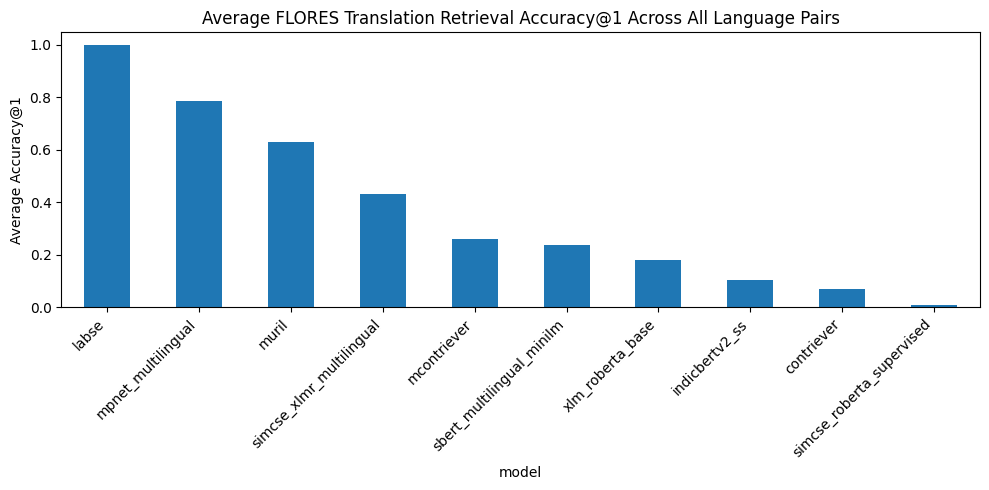

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/average_accuracy_at_1_ALL_PAIRS_dev_devtest_nfull.png


In [28]:
# ------------------------------------------------------------
# 3. Plot average Accuracy@1 by model
# ------------------------------------------------------------
# Since all-pairs has many language pairs, plotting every pair
# in one bar chart becomes too crowded.
# So this plot shows average Accuracy@1 per model.

model_avg_acc = (
    metrics_df
    .groupby("model")["accuracy_at_1"]
    .mean()
    .sort_values(ascending=False)
)

ax = model_avg_acc.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Average Accuracy@1")
ax.set_title("Average FLORES Translation Retrieval Accuracy@1 Across All Language Pairs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / f"average_accuracy_at_1_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

/tmp/ipykernel_424/2961454237.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


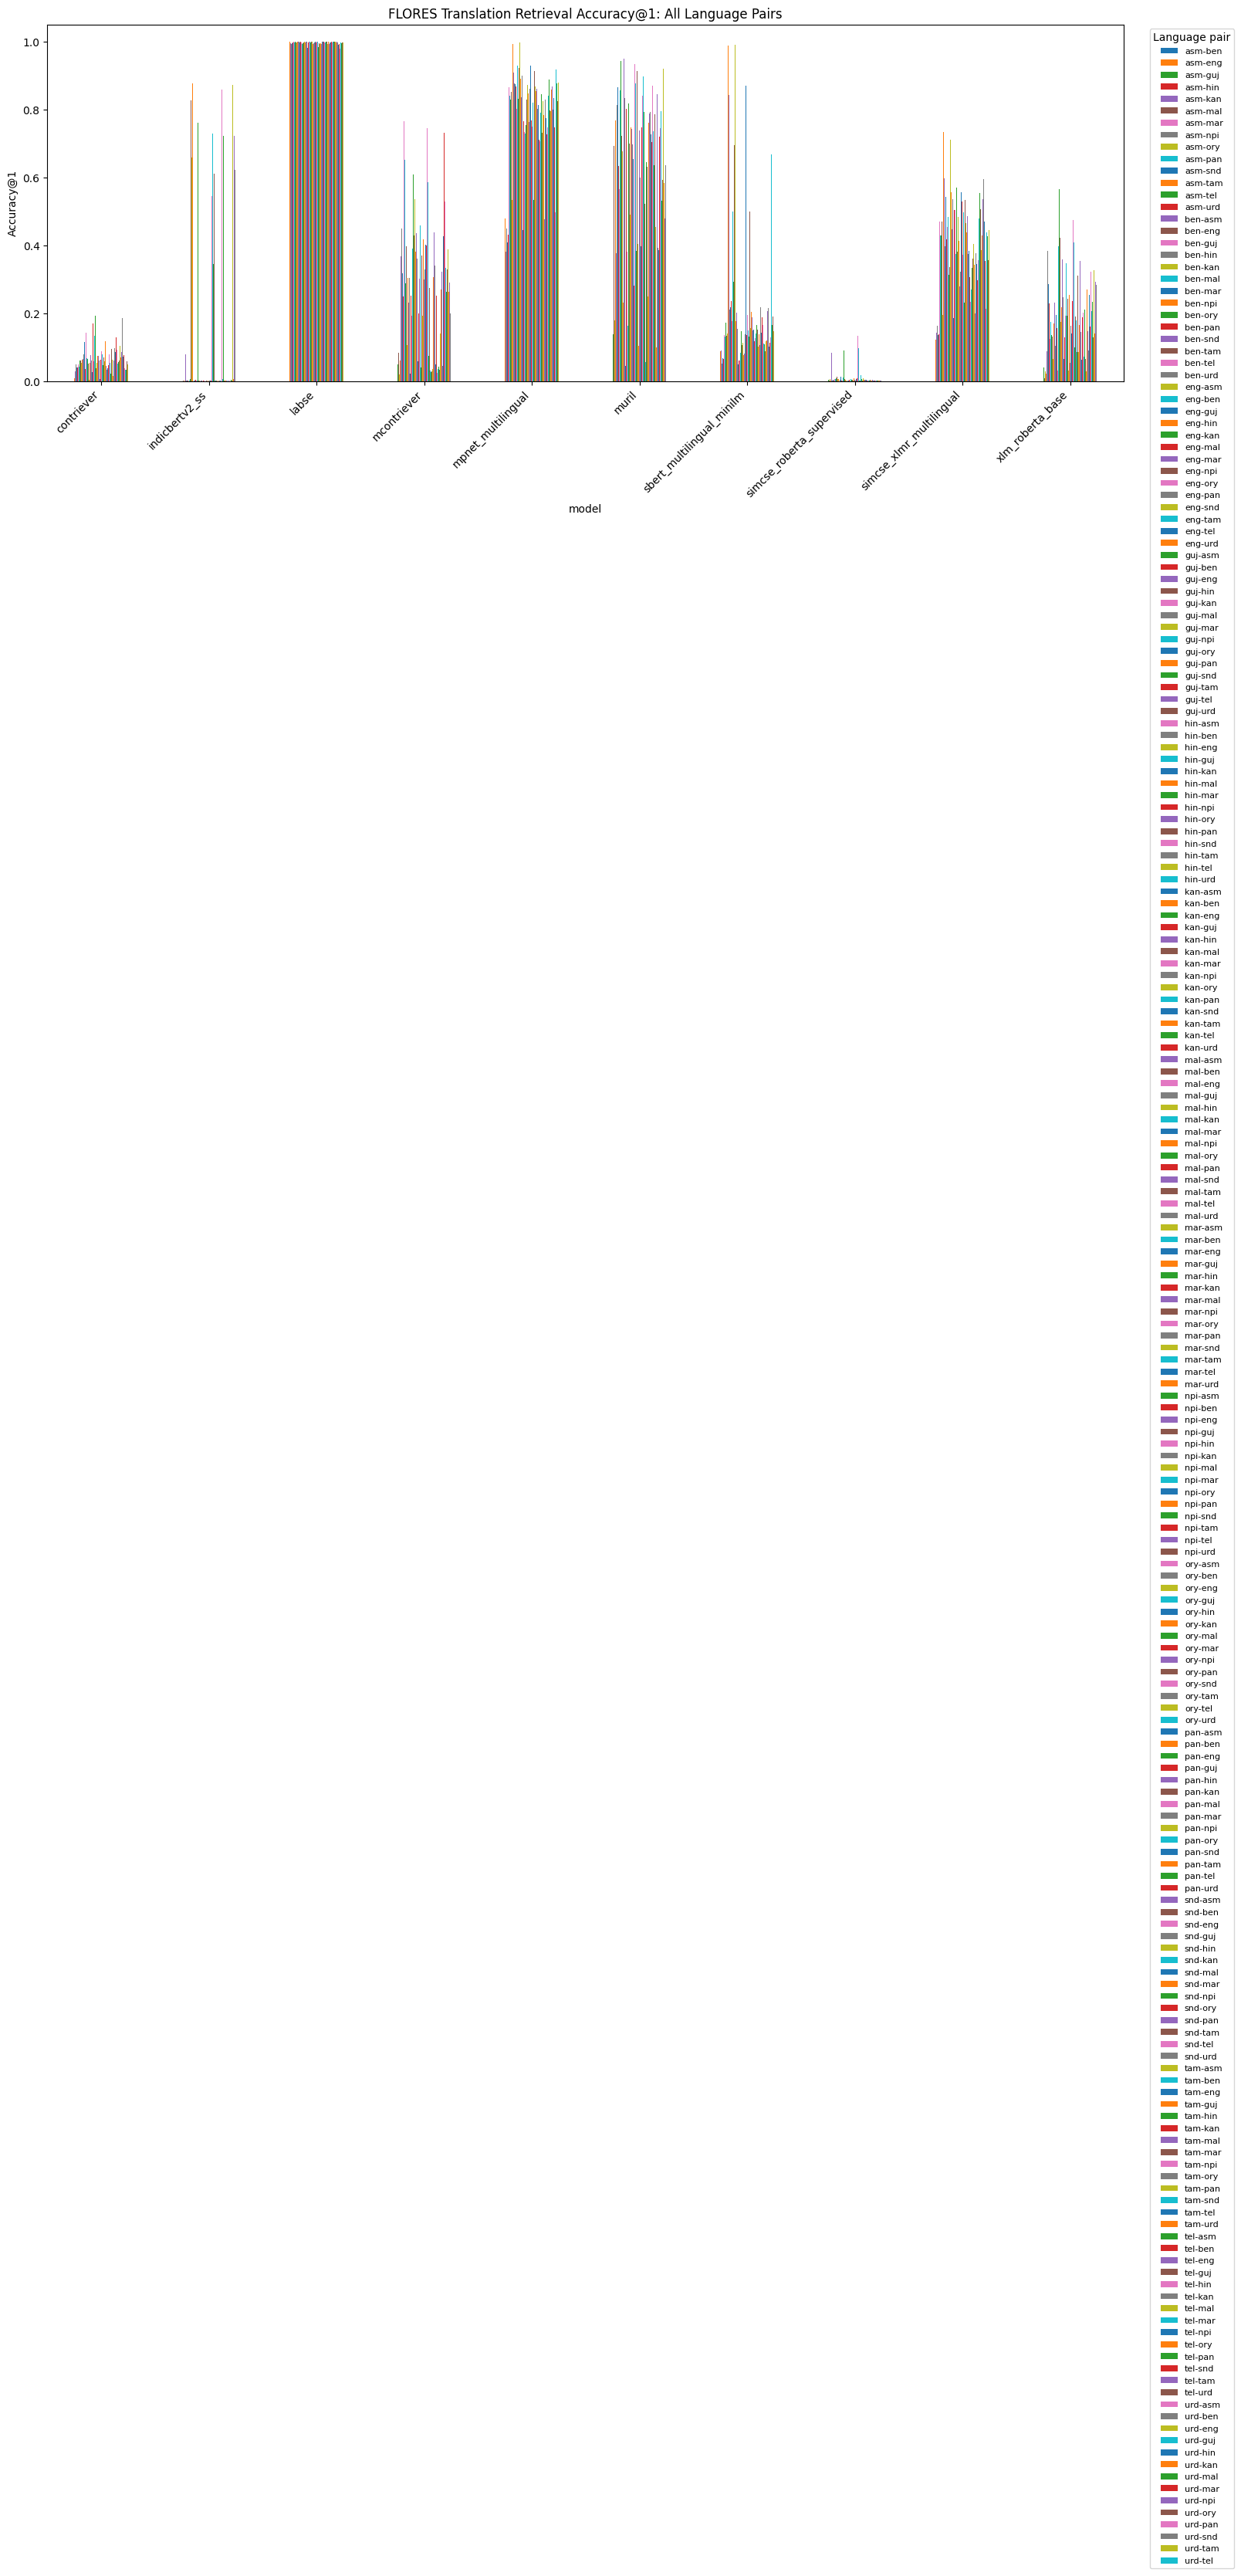

Saved plot: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/accuracy_at_1_by_model_ALL_PAIRS_dev_devtest_nfull.png


In [29]:
# ------------------------------------------------------------
# 4. Optional: plot all language pairs for each model
# ------------------------------------------------------------
# This can be crowded, but useful when you want to inspect
# every source-target direction.

pivot = metrics_df.pivot(
    index="model",
    columns="language_pair",
    values="accuracy_at_1"
)

ax = pivot.plot(kind="bar", figsize=(18, 6))
ax.set_ylabel("Accuracy@1")
ax.set_title("FLORES Translation Retrieval Accuracy@1: All Language Pairs")
ax.legend(title="Language pair", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plot_path = OUTPUT_DIR / f"accuracy_at_1_by_model_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

In [30]:
# ------------------------------------------------------------
# 5. Best and worst language pairs per model
# ------------------------------------------------------------
# This helps you quickly see where each model works well
# and where it fails.

best_pairs = (
    metrics_df
    .sort_values(["model", "accuracy_at_1"], ascending=[True, False])
    .groupby("model")
    .head(5)
)

worst_pairs = (
    metrics_df
    .sort_values(["model", "accuracy_at_1"], ascending=[True, True])
    .groupby("model")
    .head(5)
)

best_pairs_path = OUTPUT_DIR / f"best_language_pairs_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"
worst_pairs_path = OUTPUT_DIR / f"worst_language_pairs_ALL_PAIRS_{SPLIT_TAG}_n{N_TAG}.csv"

best_pairs.to_csv(best_pairs_path, index=False)
worst_pairs.to_csv(worst_pairs_path, index=False)

print("Saved best pairs:", best_pairs_path)
display(best_pairs[["model", "language_pair", "accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]])

print("Saved worst pairs:", worst_pairs_path)
display(worst_pairs[["model", "language_pair", "accuracy_at_1", "recall_at_10", "mrr", "cosine_gap"]])

Saved best pairs: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/best_language_pairs_ALL_PAIRS_dev_devtest_nfull.csv


,model,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
1762,contriever,kan-tel,0.192633,0.306122,0.233757,0.097080
1755,contriever,kan-mal,0.185167,0.312593,0.228860,0.100278
1867,contriever,tel-kan,0.185167,0.317073,0.233135,0.099544
1769,contriever,mal-kan,0.182180,0.312593,0.229798,0.101086
1865,contriever,tel-guj,0.180189,0.282230,0.215750,0.099590
636,indicbertv2_ss,eng-mar,0.887008,0.975112,0.920899,0.082870
643,indicbertv2_ss,eng-urd,0.877053,0.969139,0.910838,0.084284
826,indicbertv2_ss,urd-eng,0.873071,0.966152,0.909075,0.084476
784,indicbertv2_ss,snd-eng,0.858636,0.965157,0.897713,0.089030
686,indicbertv2_ss,hin-eng,0.840717,0.954704,0.880295,0.080205


Saved worst pairs: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/worst_language_pairs_ALL_PAIRS_dev_devtest_nfull.csv


,model,language_pair,accuracy_at_1,recall_at_10,mrr,cosine_gap
1876,contriever,urd-eng,0.003982,0.022399,0.012864,0.012915
1736,contriever,hin-eng,0.004480,0.018915,0.013124,0.016553
1708,contriever,ben-eng,0.006471,0.028870,0.016870,0.014461
1778,contriever,mar-eng,0.006969,0.024888,0.015631,0.018473
1694,contriever,asm-eng,0.007964,0.025386,0.016061,0.012823
658,indicbertv2_ss,ben-eng,0.000000,0.011946,0.005091,0.002738
684,indicbertv2_ss,guj-tel,0.000000,0.013937,0.007107,0.004700
720,indicbertv2_ss,mal-mar,0.000000,0.007466,0.004676,0.001845
727,indicbertv2_ss,mal-urd,0.000000,0.006969,0.004496,0.001307
811,indicbertv2_ss,tam-urd,0.000000,0.007466,0.004239,0.000786


## 10. Inspect error examples

This is useful for your report. It shows where the model chose the wrong nearest translation.

In [31]:
# ------------------------------------------------------------
# 6. Inspect error examples
# ------------------------------------------------------------
# Error files contain cases where the model selected the wrong nearest neighbour.

import glob

error_files = sorted(glob.glob(str(OUTPUT_DIR / "errors" / f"*_{SPLIT_TAG}_n{N_TAG}_errors.csv")))

print("Number of error files:", len(error_files))

print("\nFirst 10 error files:")
for path in error_files[:10]:
    print(path)

# Change this index to inspect another model/language pair.
ERROR_FILE_INDEX = 0

if error_files:
    sample_error_path = error_files[ERROR_FILE_INDEX]
    print("\nShowing errors from:", sample_error_path)

    sample_errors = pd.read_csv(sample_error_path)
    display(sample_errors.head(10))
else:
    print("No error files found.")

Number of error files: 2400

First 10 error files:
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-ben_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-eng_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-guj_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-hin_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-kan_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-mal_dev_devtest_nfull_errors.csv
/content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/errors/contriever_asm-mar_dev_devtest_nfull_errors.csv
/con

,row_id,source_text,gold_translation,predicted_neighbor,gold_cosine,predicted_cosine,margin_pred_minus_gold
0,385,"""Hangeul হৈছে দৈনিক ব্যৱহাৰৰ বাবে উদ্দেশ্য কৰি...",হ্যাঙ্গুল হলো জনপ্রিয় ভাবে দৈনিক ব্যবহারে উদ্...,"""""""এগুলো পার্শ্ববর্তী পৃষ্ঠের চেয়ে দিনের বেলা...",0.670077,0.882326,0.212249
1,118,খেল প্ৰকাশক কোনামিয়ে আজি এখন জাপানী বাতৰি কাকত...,গেমের প্রকাশক Konami একটি জাপানি সংবাদপত্রে আজ...,জাতিসংঘ বৈশ্বিক উষ্ণতা দ্বারা আক্রান্ত দেশগুলো...,0.751399,0.956184,0.204785
2,45,"২৪ ছেপ্টেম্বৰ, ১৭৫৯-ত আৰ্থাৰ গিনিজে ডাব্লিন, আ...",1759 সালের 24 শে সেপ্টেম্বর আর্থার গিনিস আয়ারল...,এটি ফুরিয়ে গেলে অনায়াসেই তা পূরণীয় হবে এবং তাত...,0.727615,0.926916,0.199301
3,723,ফ্ৰেৰী বাৰ্টুলুম ডি লাছ কেছাছৰ (ট্ৰাটাডু ডি লা...,1492 থেকে 1498 সালের মধ্যে স্পেনীয় বিজয়ীরা ফ...,৮ই জুলাই ইন্ডিপেন্ডেন্স হলের আঙিনায় জন নিক্সন ...,0.750669,0.935749,0.185080
4,288,"""""""চিচিটিভিটোৱে নিশ্চিতভাৱে জন্তুবোৰৰ সৈতে কাম...","যাঁরা পশুদের নিয়ে কাজ করেন, সিসিটিভি তাঁদের উদ...","""""""কেউ একমত নাও হতে পারে কিন্তু আমার তাতে কিছু...",0.770960,0.939362,0.168402
5,287,RSPCAৰ নিউ ছাউথ ৱেলছৰ মুখ্য পৰিদৰ্শক ডেভিদ অ'ছ...,RSPCA নিউ সাউথ ওয়েলসের চিফ ইন্সপেক্টর ডেভিড ও...,রাতজুড়ে ব্যাপক লুণ্ঠন চলছে কারণ বিশকেক'স স্ট্র...,0.767100,0.932048,0.164948
6,122,"""কেনিয়াৰ নাইৰোবিত অৱস্থিত আমেৰিকা যুক্তৰাষ্ট্ৰ...","কেনিয়ার নাইরোবিতে অবস্থিত মার্কিন দূতাবাস, এক...","""""""মন্ত্রণালয় অ্যাপলের এই প্রতিবেদনটিকে স্থগি...",0.755441,0.919906,0.164465
7,147,য়াহু! আৰু মাইক্র’চ’ফ্টৰ যুটীয়া সেৱাৰ উপভোক্ত...,Yahoo! এবং মাইক্রোসফ্ট পরিসেবা ব্যবহারকারীর সং...,"যাইহোক, যারা অল্পস্বল্প স্প্যানিশ জানেন তারা় ...",0.743523,0.907222,0.163698
8,463,"""দুৰ্ভাগ্যবশত ভাৱে, যেতিয়া আপুনি এখন ডিভিডি নি...","দুর্ভাগ্যবশত, আপনি যখন DVD তৈরী করেন, তখন সম্ভ...","""এর দ্বিতীয় নখটি ছিল অপেক্ষাকৃত বড়, যা হেসপার...",0.785915,0.949363,0.163447
9,1813,এইটো প্ৰত্যাশিত আছিল যে বেছিভাগ কাৰ্য্যসূচীৰ ট...,"বেশিরভাগ ইভেন্টের ক্ষেত্রে টিকিটের দাম ¥2,500 ...","হাজার হাজার বছর আগে, আরিস্টারকাস নামের একজন লো...",0.754020,0.916570,0.162550


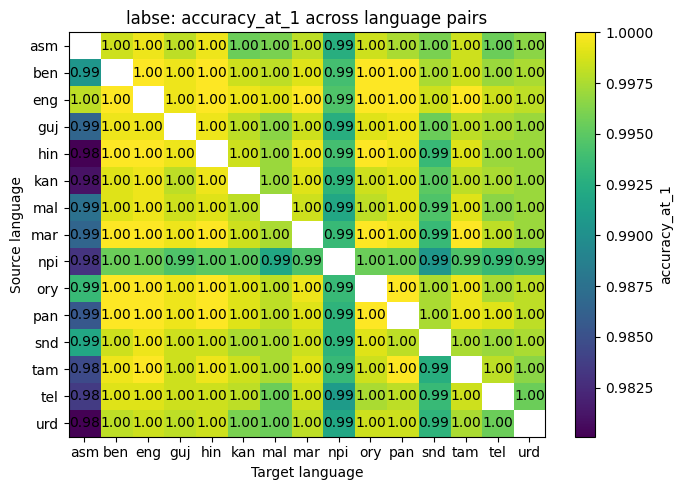

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/labse_accuracy_at_1_heatmap_dev_devtest_nfull.png


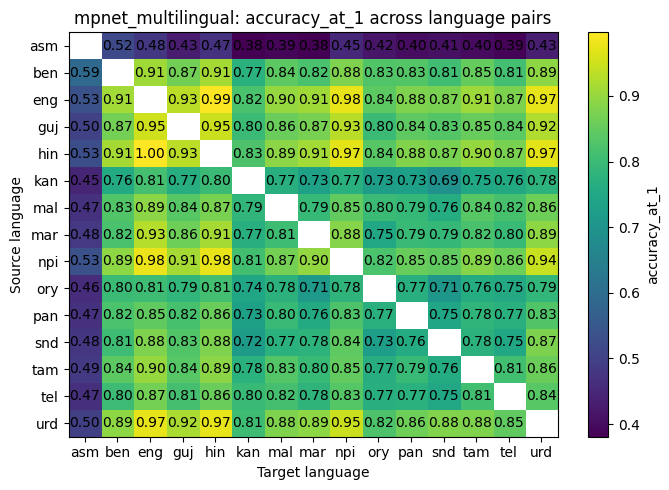

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/mpnet_multilingual_accuracy_at_1_heatmap_dev_devtest_nfull.png


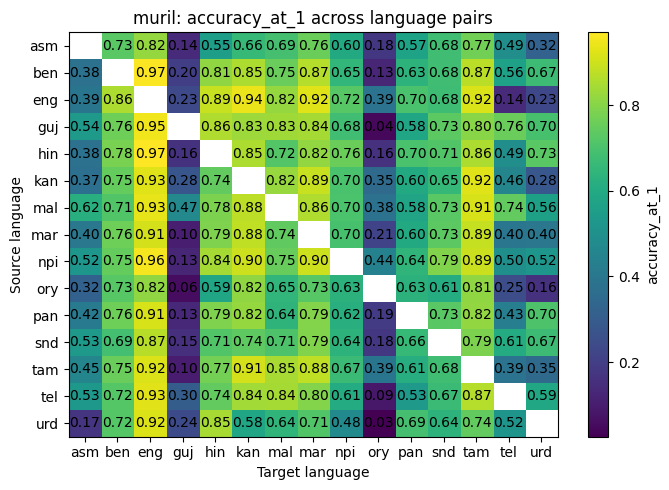

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/muril_accuracy_at_1_heatmap_dev_devtest_nfull.png


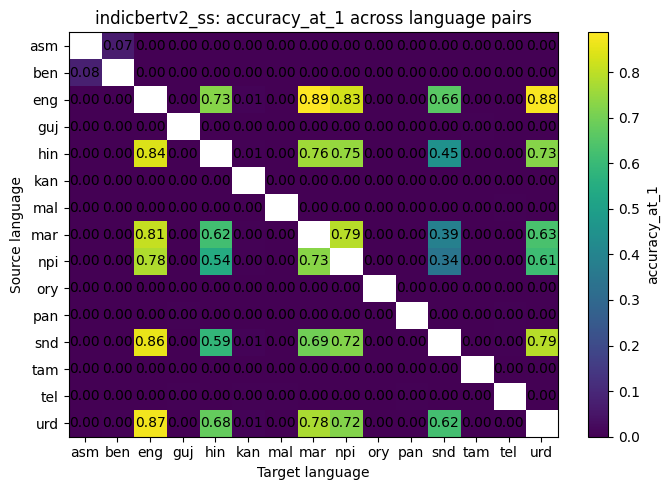

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/indicbertv2_ss_accuracy_at_1_heatmap_dev_devtest_nfull.png


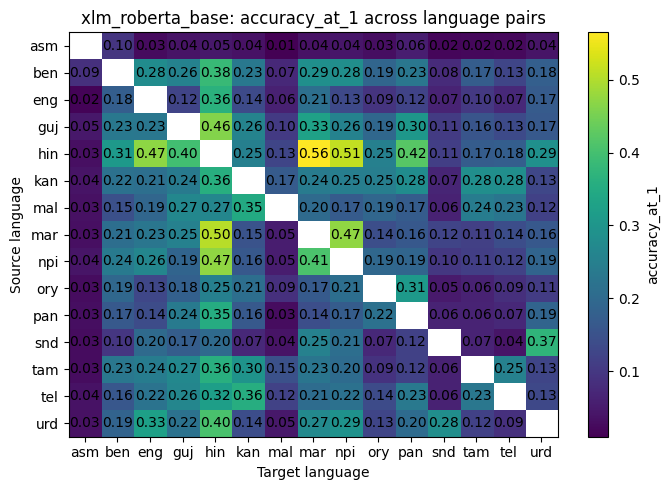

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/xlm_roberta_base_accuracy_at_1_heatmap_dev_devtest_nfull.png


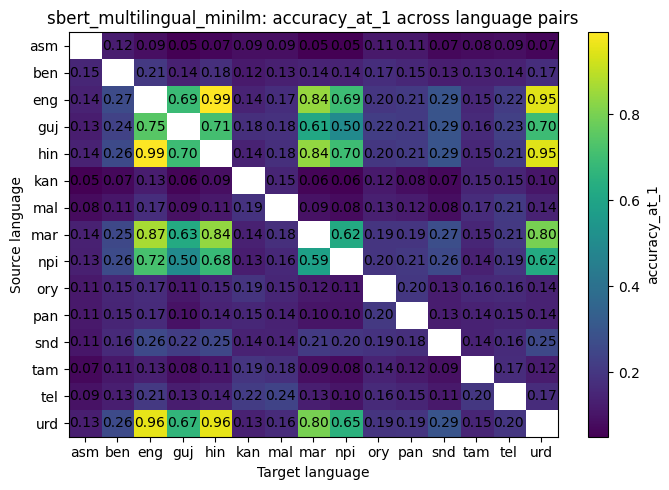

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/sbert_multilingual_minilm_accuracy_at_1_heatmap_dev_devtest_nfull.png


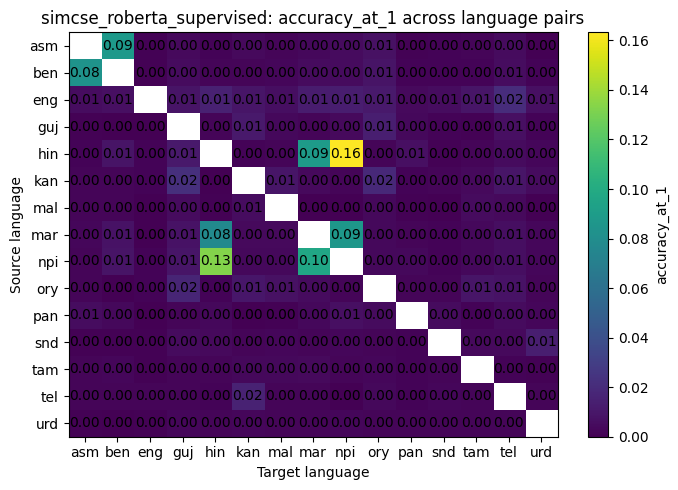

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/simcse_roberta_supervised_accuracy_at_1_heatmap_dev_devtest_nfull.png


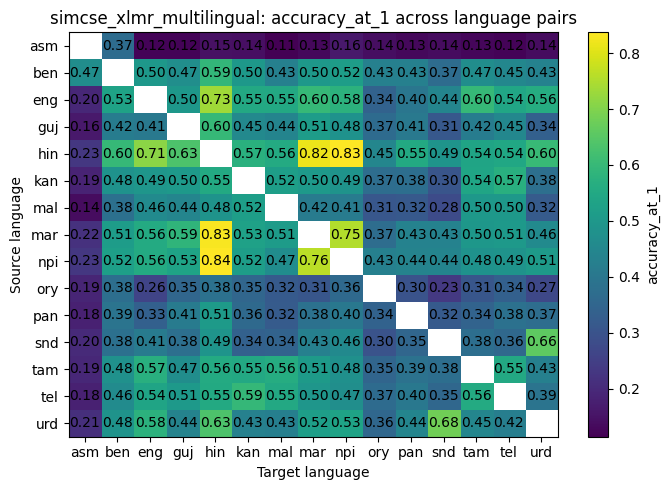

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/simcse_xlmr_multilingual_accuracy_at_1_heatmap_dev_devtest_nfull.png


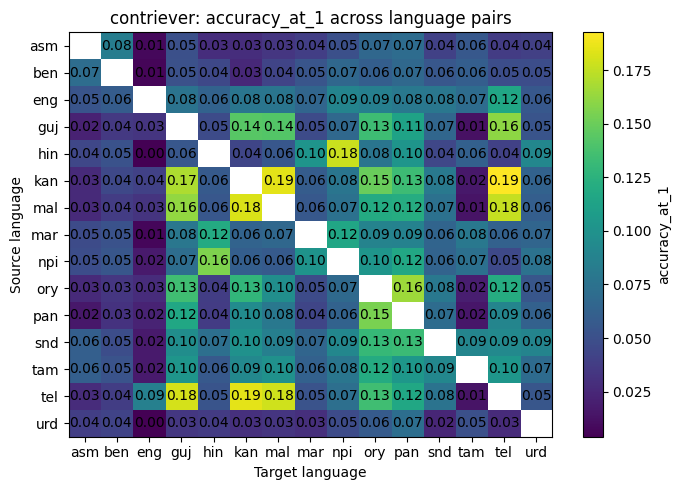

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/contriever_accuracy_at_1_heatmap_dev_devtest_nfull.png


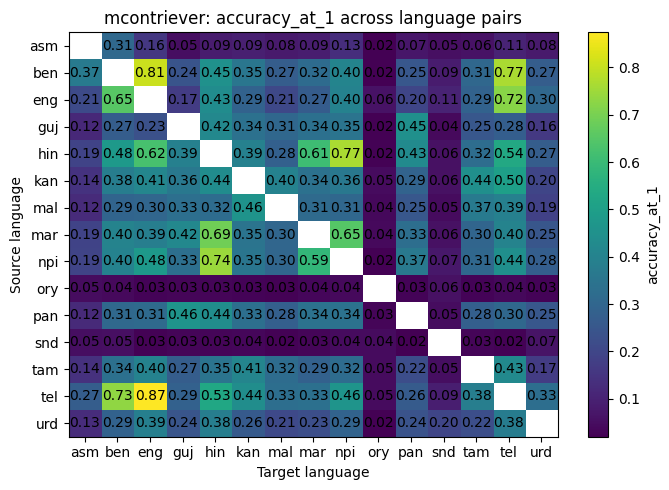

Saved heatmap: /content/drive/MyDrive/indic_embedding_benchmark/outputs/flores_alignment_colab/mcontriever_accuracy_at_1_heatmap_dev_devtest_nfull.png


In [32]:
def plot_model_heatmap(metrics_df, model_name, metric="accuracy_at_1"):
    model_df = metrics_df[metrics_df["model"] == model_name]

    heatmap_data = model_df.pivot(
        index="source_language",
        columns="target_language",
        values=metric
    )

    plt.figure(figsize=(7, 5))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label=metric)

    plt.xticks(
        ticks=range(len(heatmap_data.columns)),
        labels=heatmap_data.columns
    )
    plt.yticks(
        ticks=range(len(heatmap_data.index)),
        labels=heatmap_data.index
    )

    plt.title(f"{model_name}: {metric} across language pairs")
    plt.xlabel("Target language")
    plt.ylabel("Source language")

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                plt.text(j, i, f"{value:.2f}", ha="center", va="center")

    plt.tight_layout()

    plot_path = OUTPUT_DIR / f"{model_name}_{metric}_heatmap_{SPLIT_TAG}_n{N_TAG}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print("Saved heatmap:", plot_path)
for model_name in metrics_df["model"].unique():
    plot_model_heatmap(metrics_df, model_name, metric="accuracy_at_1")

## 11. How to interpret results

Use this simple interpretation:

- **High positive cosine mean**: translation pairs are close.
- **Low random cosine mean**: unrelated cross-language pairs are not too close.
- **Large cosine gap**: good alignment separation.
- **High Accuracy@1**: the model can retrieve the correct translation as the nearest neighbor.
- **High Recall@10**: the correct translation is at least among the top 10 candidates.

For the mentor report, prioritize models with strong **Accuracy@1 + MRR + cosine gap**.
